In [3]:
import os
from glob import glob
import SimpleITK as sitk
import matplotlib.pyplot as plt
import numpy as np
from scipy.ndimage import zoom
# from skimage.metrics import peak_signal_noise_ratio as psnr
# from skimage.metrics import structural_similarity as ssim
# from skimage.metrics import normalized_root_mse as nrmse


# from cardiac.bulleye_gen import gen_bulleye
from cardiac.segment.functions import naive_segment_lv_mask, naive_cal_circle_param
# from cardiac.segment.advanced_segment import cal_lv_mask, naive_locate

from cardiac.segment.functions import naive_locate, naive_cal_myocardium_line_param, recursive_search_myocardium_line_param, generate_mask3d_from_param

from cardiac.segment.visualize import visualize



In [4]:
def read_sitk_img(path, zoom_factor = 3):
    sitk_img = sitk.ReadImage(path)
    img_arr = sitk.GetArrayFromImage(sitk_img)
    width = 20
    # 计算中心位置
    center = np.array(img_arr.shape)//2
    start = center - width//2
    end = center + width//2
    
    clipped_img_arr = img_arr[:, start[1]:end[1], start[2]:end[2]].copy()
    
    # zoom_factor = 3
    zoomed_clipped_img_arr = zoom(clipped_img_arr, zoom_factor, cval=0)
    voxel_size = np.array(sitk_img.GetSpacing()[::-1])/zoom_factor
    return zoomed_clipped_img_arr, voxel_size


In [ ]:
base_dir = r"Y:\labspace\DataCollection\Project\RadiSmart\cardiac\all_nii"
dir_names = sorted(os.listdir(base_dir))[:5]

for dir_name in dir_names:
    img_paths = glob(os.path.join(base_dir, dir_name, "*.nii.gz"))
    if len(img_paths) < 2:
        continue
    
    img_path = glob(os.path.join(base_dir, dir_name, "SA*.nii.gz"))[0]
    img3d, voxel_size = read_sitk_img(img_path, 3)
    
    
    print(f"{dir_name}")
    print(img3d.shape, voxel_size)
    naive_param = naive_locate(img3d, voxel_size, verbose=2)
    naive_myocardium_line_param = naive_cal_myocardium_line_param(img3d, naive_param, verbose=2)
    

    


In [70]:
import numpy as np

def get_sector_masks_by_spherical_coords(img3d, center, radius):
    """
    Create masks for sectors based on spherical coordinates (r, theta, phi)
    
    Args:
        img3d: 3D numpy array
        center: (cz, cy, cx) center coordinates 
        radius: radius of hemisphere
        
    Returns:
        sector_masks: 3D array with sector index values
    """
    cz, cy, cx = center
    
    # Create coordinate grids
    Z, Y, X = np.ogrid[:img3d.shape[0], :img3d.shape[1], :img3d.shape[2]]
    
    # Calculate distances and angles from center for each point
    dz = Z - cz + 0.5 
    dy = Y - cy + 0.5
    dx = X - cx + 0.5
    
    # Distance (r)
    distance2center = np.sqrt(dz**2 + dy**2 + dx**2)
    
    # Azimuth angle (theta) [-pi, pi]
    theta = np.arctan2(dy, dx)+dz*0
    
    # Elevation angle (phi) [0, pi/2] 
    phi = np.arccos(dz/(distance2center))
    phi[distance2center == 0] = 0 # Handle division by zero
    
    
    # Create sector masks based on r, theta, phi ranges
    sector_masks = np.zeros_like(img3d)
    
    # Only include points within radius and upper hemisphere (changed from lower to upper)
    hemisphere_mask = (distance2center <= radius) & (dz <= 0)  # Changed from dz >= 0 to dz <= 0

    theta_bins = np.linspace(-np.pi, np.pi, 40+1) # 9 degree steps
    # print(theta_bins)
    phi_bins = np.array(range(9))*12/180*np.pi + np.pi/2# 12 degree steps
    # print(phi_bins)
    
    # Vectorized sector assignment using digitize
    theta_indices = np.digitize(theta, theta_bins)-1
    phi_indices = np.digitize(phi, phi_bins)-1
    
    # Only assign indices where hemisphere_mask is True
    valid_mask = (theta_indices >= 0) & (theta_indices < len(theta_bins)) & \
                 (phi_indices >= 0) & (phi_indices < len(phi_bins)) & \
                 hemisphere_mask
    
    # print()
    # print(phi_indices.shape, np.unique(phi_indices))
    # print(hemisphere_mask.shape, np.unique(hemisphere_mask))
    # print(valid_mask.shape, np.unique(valid_mask))
    # return valid_mask
                 
    # Calculate sector indices vectorized
    sector_indices = (theta_indices) * len(phi_bins) + (phi_indices) + 1
    sector_masks[valid_mask] = sector_indices[valid_mask]
    
    # central_conone_mask = (phi>=2*np.pi-6/180*np.pi ) & hemisphere_mask
    central_conone_mask = (phi_indices>=7 ) & hemisphere_mask
    sector_masks[central_conone_mask] = np.max(sector_masks)+1
    
    return sector_masks

# Example usage:
center = (20, 26, 28) # Example center coordinates  
radius = 16 # Example radius
sector_masks = get_sector_masks_by_spherical_coords(img3d, center, radius)

print(np.unique(sector_masks), len(np.unique(sector_masks)))

[  0   1   2   3   4   5   6   7  10  11  12  13  14  15  16  19  20  21
  22  23  24  25  28  29  30  31  32  33  34  37  38  39  40  41  42  46
  47  48  49  50  51  52  55  56  57  58  59  60  61  64  65  66  67  68
  69  70  73  74  75  76  77  78  79  82  83  84  85  86  87  88  91  92
  93  94  95  96  97 100 101 102 103 104 105 106 109 110 111 112 113 114
 115 118 119 120 121 122 123 124 127 128 129 130 131 132 136 137 138 139
 140 141 142 145 146 147 148 149 150 151 154 155 156 157 158 159 160 163
 164 165 166 167 168 169 172 173 174 175 176 177 178 181 182 183 184 185
 186 187 190 191 192 193 194 195 196 199 200 201 202 203 204 205 208 209
 210 211 212 213 214 217 218 219 220 221 222 226 227 228 229 230 231 232
 235 236 237 238 239 240 241 244 245 246 247 248 249 250 253 254 255 256
 257 258 259 262 263 264 265 266 267 268 271 272 273 274 275 276 277 280
 281 282 283 284 285 286 289 290 291 292 293 294 295 298 299 300 301 302
 303 304 307 308 309 310 311 312 316 317 318 319 32

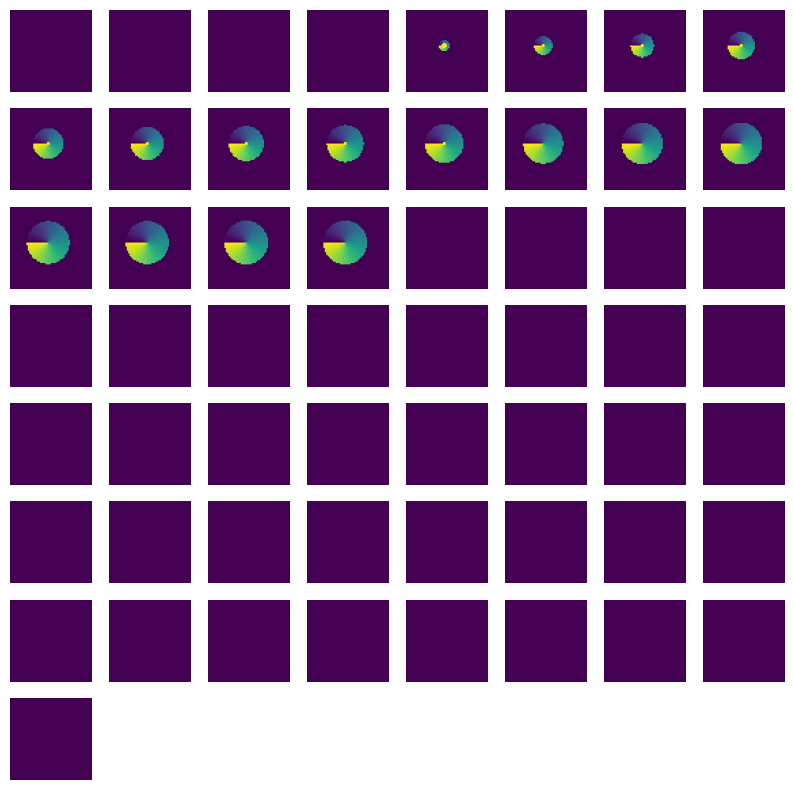

In [69]:
plt.figure(figsize=(10, 10))


# sector_masks[sector_masks!=50] = 0
for i in range(sector_masks.shape[0]):
    plt.subplot(8,8,i+1)
    plt.imshow(sector_masks[i], vmax=sector_masks.max())
    plt.axis('off')
plt.show()


In [26]:
import numpy as np
np.array(range(9))* 12 

array([ 0, 12, 24, 36, 48, 60, 72, 84, 96])

In [13]:
np.linspace(0, 10, 11)

array([ 0.,  1.,  2.,  3.,  4.,  5.,  6.,  7.,  8.,  9., 10.])